# 01 – Data Ingestion & Exploratory Data Analysis

**Goal:** Load raw Sephora data from S3, store it in a query-ready curated layer, then explore the data to guide feature engineering.

| Section | Description |
|---|---|
| 1 | Setup — imports, AWS config |
| 2 | Ingestion — load CSVs, combine review shards, convert to Parquet |
| 3 | Athena — register curated tables for SQL access |
| 4 | Schema & statistics — dtypes, missing values, basic stats |
| 5 | Distributions — histograms and boxplots |
| 6 | Correlations — numeric feature heatmaps |
| 7 | Brand & category — who dominates the catalogue |
| 8 | Price analysis — price vs rating relationships |
| 9 | Helpfulness analysis — what makes a review useful |
| 10 | Loves-count analysis — popularity drivers |

**Input:** `s3://ads508-team1-sephora/raw/`  
**Output:** `s3://ads508-team1-sephora/curated/` + Athena tables

## 1. Setup

In [1]:
import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sagemaker
import warnings
from pyathena import connect

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# AWS session
sess   = sagemaker.Session()
region = boto3.Session().region_name
role   = sagemaker.get_execution_role()

# ── S3 paths 
BUCKET           = 'ads508-team1-sephora'
DATABASE_NAME    = 'sephora_reviews_db'
S3_STAGING       = f's3://{BUCKET}/athena/staging/'
RAW_PRODUCTS     = f's3://{BUCKET}/raw/products/product_info.csv'
RAW_REVIEWS_DIR  = f's3://{BUCKET}/raw/reviews/'
CURATED_REVIEWS  = f's3://{BUCKET}/curated/reviews/'
CURATED_PRODUCTS = f's3://{BUCKET}/curated/products/'

print(f'Region : {region}')
print(f'Bucket : {BUCKET}')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Region : us-east-1
Bucket : ads508-team1-sephora


## 2. Data Ingestion

Products arrive as a single CSV. Reviews are split across 5 shards; we combine them into one DataFrame, then write both as Parquet to the curated layer.

In [2]:
#  Products 
products = pd.read_csv(RAW_PRODUCTS)
print(f'Products : {products.shape}  ({products.shape[1]} columns)')

#  Reviews — combine 5 shards 
shard_files = [
    f'{RAW_REVIEWS_DIR}reviews_0-250.csv',
    f'{RAW_REVIEWS_DIR}reviews_250-500.csv',
    f'{RAW_REVIEWS_DIR}reviews_500-750.csv',
    f'{RAW_REVIEWS_DIR}reviews_750-1250.csv',
    f'{RAW_REVIEWS_DIR}reviews_1250-end.csv',
]
reviews = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
reviews = reviews.loc[:, ~reviews.columns.str.contains('^Unnamed')]
reviews['author_id'] = reviews['author_id'].astype(str)   # consistent dtype
print(f'Reviews  : {reviews.shape}  ({reviews.shape[1]} columns)')

Products : (8494, 27)  (27 columns)
Reviews  : (1094411, 18)  (18 columns)


In [3]:
#  Write to curated layer (Parquet)
products.to_parquet(f'{CURATED_PRODUCTS}products.parquet', engine='pyarrow', index=False)
reviews.to_parquet( f'{CURATED_REVIEWS}reviews.parquet',  engine='pyarrow', index=False)
print('Parquet files written to curated layer.')

Parquet files written to curated layer.


## 3. Athena Registration

Register both Parquet datasets as external tables so they can be queried with SQL directly from S3.

In [4]:
conn   = connect(s3_staging_dir=S3_STAGING, region_name=region)
cursor = conn.cursor()

cursor.execute(
    "CREATE EXTERNAL TABLE IF NOT EXISTS sephora_reviews ("
    "    author_id string, rating int, is_recommended boolean,"
    "    helpfulness double, total_feedback_count int,"
    "    total_neg_feedback_count int, total_pos_feedback_count int,"
    "    submission_time string, review_text string, review_title string,"
    "    skin_tone string, eye_color string, skin_type string, hair_color string,"
    "    product_id string, product_name string, brand_name string, price_usd double"
    ") STORED AS PARQUET LOCATION '" + CURATED_REVIEWS + "';"
)

cursor.execute(
    "CREATE EXTERNAL TABLE IF NOT EXISTS sephora_products ("
    "    product_id string, product_name string, brand_id string, brand_name string,"
    "    loves_count int, rating double, reviews int, size string,"
    "    variation_type string, variation_value string, variation_desc string,"
    "    ingredients string, price_usd double, value_price_usd double, sale_price_usd double,"
    "    limited_edition boolean, new boolean, online_only boolean,"
    "    out_of_stock boolean, sephora_exclusive boolean, highlights string,"
    "    primary_category string, secondary_category string, tertiary_category string,"
    "    child_count int, child_max_price double, child_min_price double"
    ") STORED AS PARQUET LOCATION '" + CURATED_PRODUCTS + "';"
)

print('Athena tables registered: sephora_reviews, sephora_products')

Athena tables registered: sephora_reviews, sephora_products


---
## 4. Schema & Summary Statistics

Quick audit of column types, missing values, and cardinality before plotting.

In [16]:
def eda_summary(df, name):
    summary = pd.DataFrame({
        'dtype':     df.dtypes.values,
        'missing_n':     df.isnull().sum().values,
        'missing_%': (df.isnull().mean() * 100).round(1).values,
        'unique':    df.nunique().values,
        'sample':    df.apply(lambda c: list(c.dropna().unique()[:3])).values,
    }, index=df.columns)
    print(f'\n── {name} ({df.shape[0]:,} rows x {df.shape[1]} cols) ──')
    return summary

display(eda_summary(products, 'Products'))
display(eda_summary(reviews,  'Reviews'))


── Products (8,494 rows x 27 cols) ──


,dtype,missing_n,missing_%,unique,sample
product_id,object,0,0.0,8494,"[P473671, P473668, P473662]"
product_name,object,0,0.0,8415,"[Fragrance Discovery Set, La Habana Eau de Par..."
brand_id,int64,0,0.0,304,"[6342, 6471, 6485]"
brand_name,object,0,0.0,304,"[19-69, 54 Thrones, ABBOTT]"
loves_count,int64,0,0.0,7436,"[6320, 3827, 3253]"
rating,float64,278,3.3,4394,"[3.6364, 4.1538, 4.25]"
reviews,float64,278,3.3,1556,"[11.0, 13.0, 16.0]"
size,object,1631,19.2,2055,"[3.4 oz/ 100 mL, 0.25 oz/ 7.5 mL, 6 oz / 180 mL]"
variation_type,object,1444,17.0,7,"[Size + Concentration + Formulation, Scent, Size]"
variation_value,object,1598,18.8,2729,"[3.4 oz/ 100 mL, 0.25 oz/ 7.5 mL Eau de Parfum..."



── Reviews (1,094,411 rows x 19 cols) ──


,dtype,missing_n,missing_%,unique,sample
author_id,object,0,0.0,503216,"[1741593524, 31423088263, 5061282401]"
rating,int64,0,0.0,5,"[5, 1, 4]"
is_recommended,float64,167988,15.3,2,"[1.0, 0.0]"
helpfulness,float64,561592,51.3,3767,"[1.0, 0.25, 0.4444440007209778]"
total_feedback_count,int64,0,0.0,676,"[2, 0, 1]"
total_neg_feedback_count,int64,0,0.0,259,"[0, 6, 5]"
total_pos_feedback_count,int64,0,0.0,590,"[2, 0, 1]"
submission_time,object,0,0.0,5317,"[2023-02-01, 2023-03-21, 2023-03-20]"
review_text,object,1444,0.1,969419,[I use this with the Nudestix “Citrus Clean Ba...
review_title,object,310654,28.4,364105,"[Taught me how to double cleanse!, Disappointe..."


In [17]:
print("Reviews info:")
reviews.info()
print("\nProducts info:")
products.info()

Reviews info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   author_id                 1094411 non-null  object 
 1   rating                    1094411 non-null  int64  
 2   is_recommended            926423 non-null   float64
 3   helpfulness               532819 non-null   float64
 4   total_feedback_count      1094411 non-null  int64  
 5   total_neg_feedback_count  1094411 non-null  int64  
 6   total_pos_feedback_count  1094411 non-null  int64  
 7   submission_time           1094411 non-null  object 
 8   review_text               1092967 non-null  object 
 9   review_title              783757 non-null   object 
 10  skin_tone                 923872 non-null   object 
 11  eye_color                 884783 non-null   object 
 12  skin_type                 982854 non-null   object 
 13  hair_color   

## 5. Distributions

### Numeric Distributions – Reviews
Histograms show the shape of numeric features. Boxplots reveal outliers.  
Key expectation: price, loves_count, and reviews are right-skewed and will need log transforms.

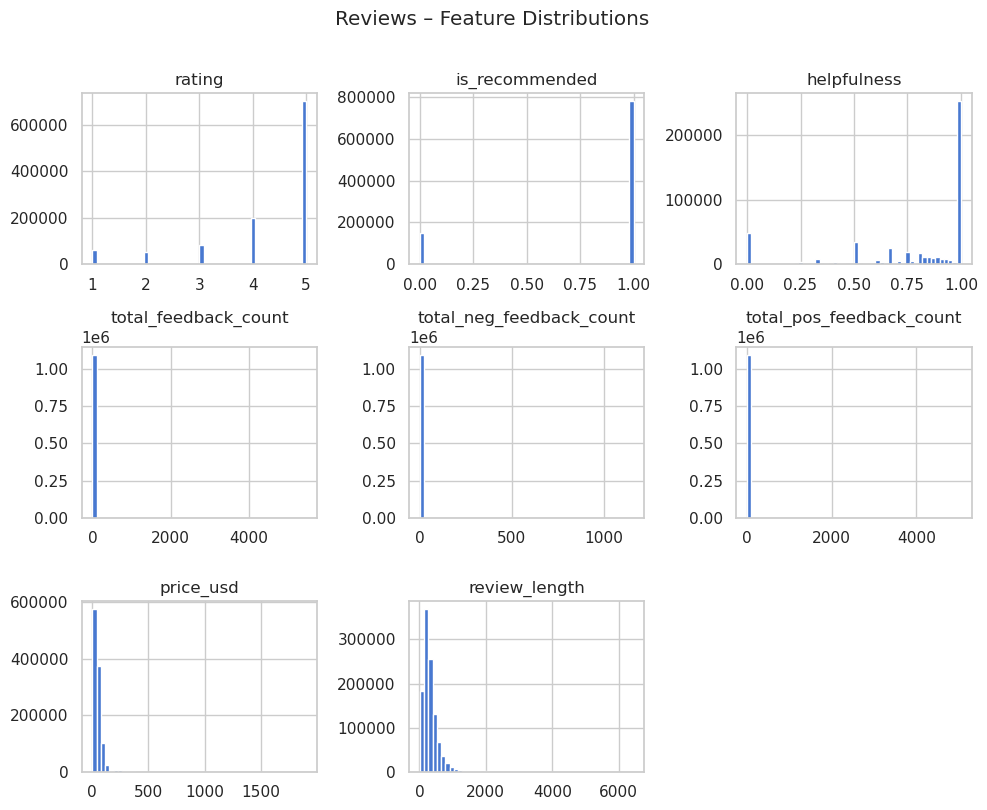

In [21]:
reviews.hist(figsize=(10, 8), bins=50)
plt.suptitle("Reviews – Feature Distributions", y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Boxplots – Reviews

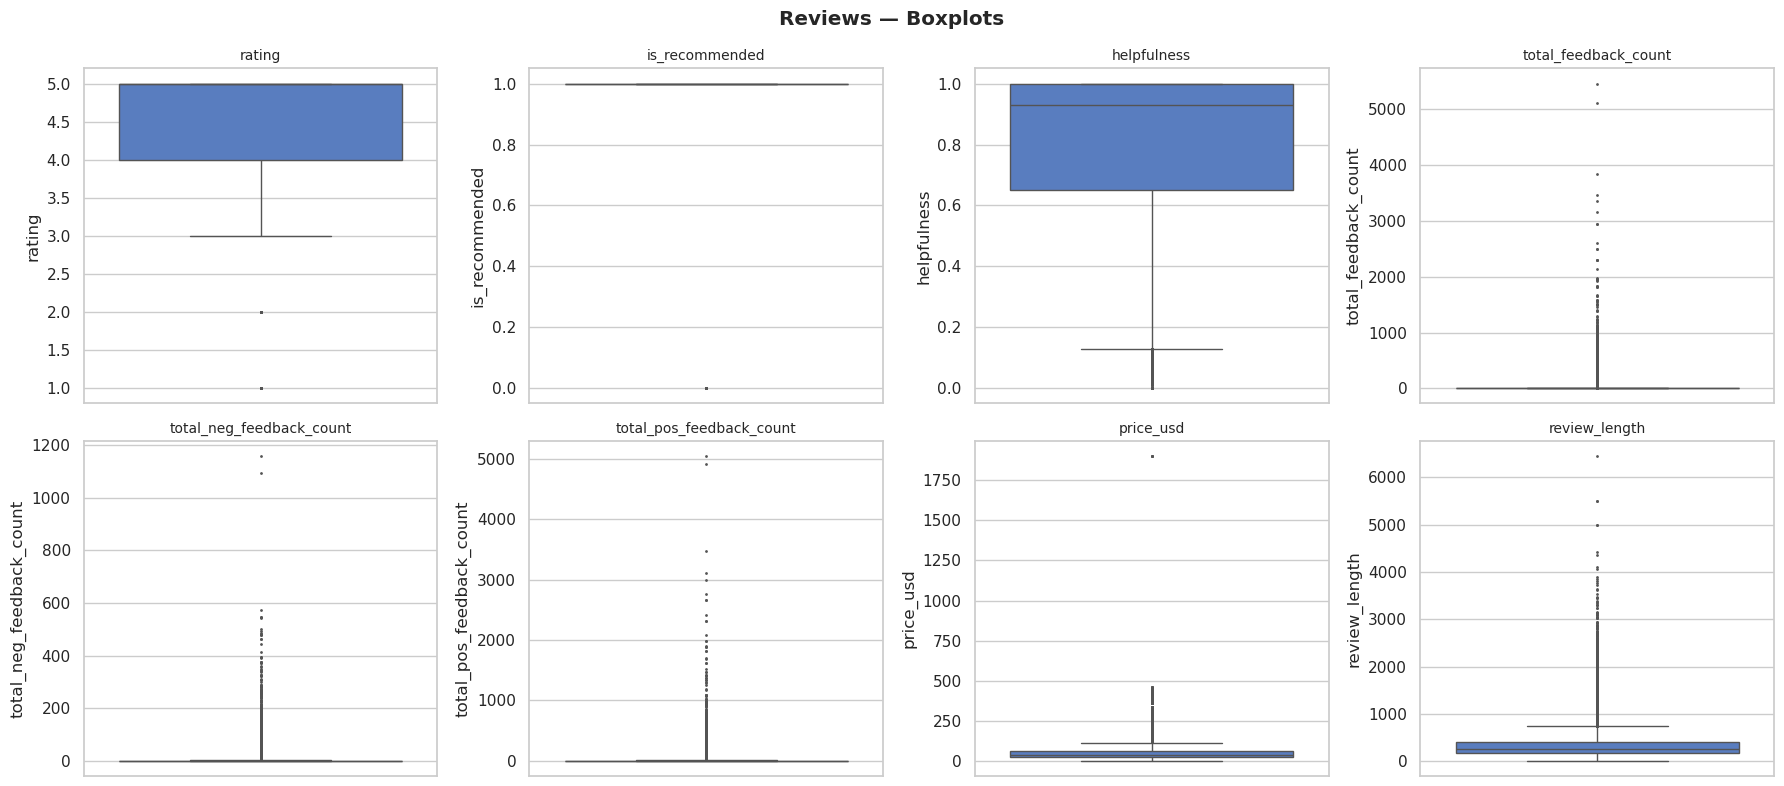

In [25]:
def boxplot_grid(df, title):
    num_cols = df.select_dtypes('number').columns.tolist()
    ncols = 4
    nrows = int(np.ceil(len(num_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        sns.boxplot(y=df[col], ax=axes[i], fliersize=1)
        axes[i].set_title(col, fontsize=10)
    for ax in axes[len(num_cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

boxplot_grid(reviews,  'Reviews — Boxplots')

### 4.3 Numeric Distributions – Products

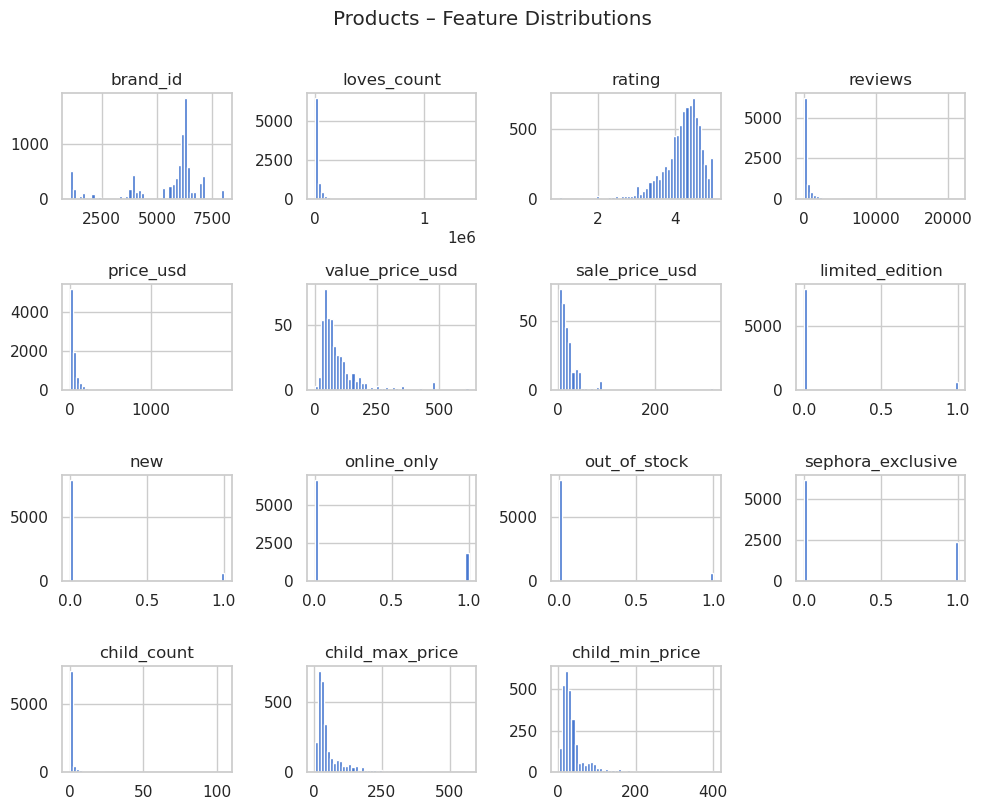

In [28]:
products.hist(figsize=(10, 8), bins=50)
plt.suptitle("Products – Feature Distributions", y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Boxplots – Products

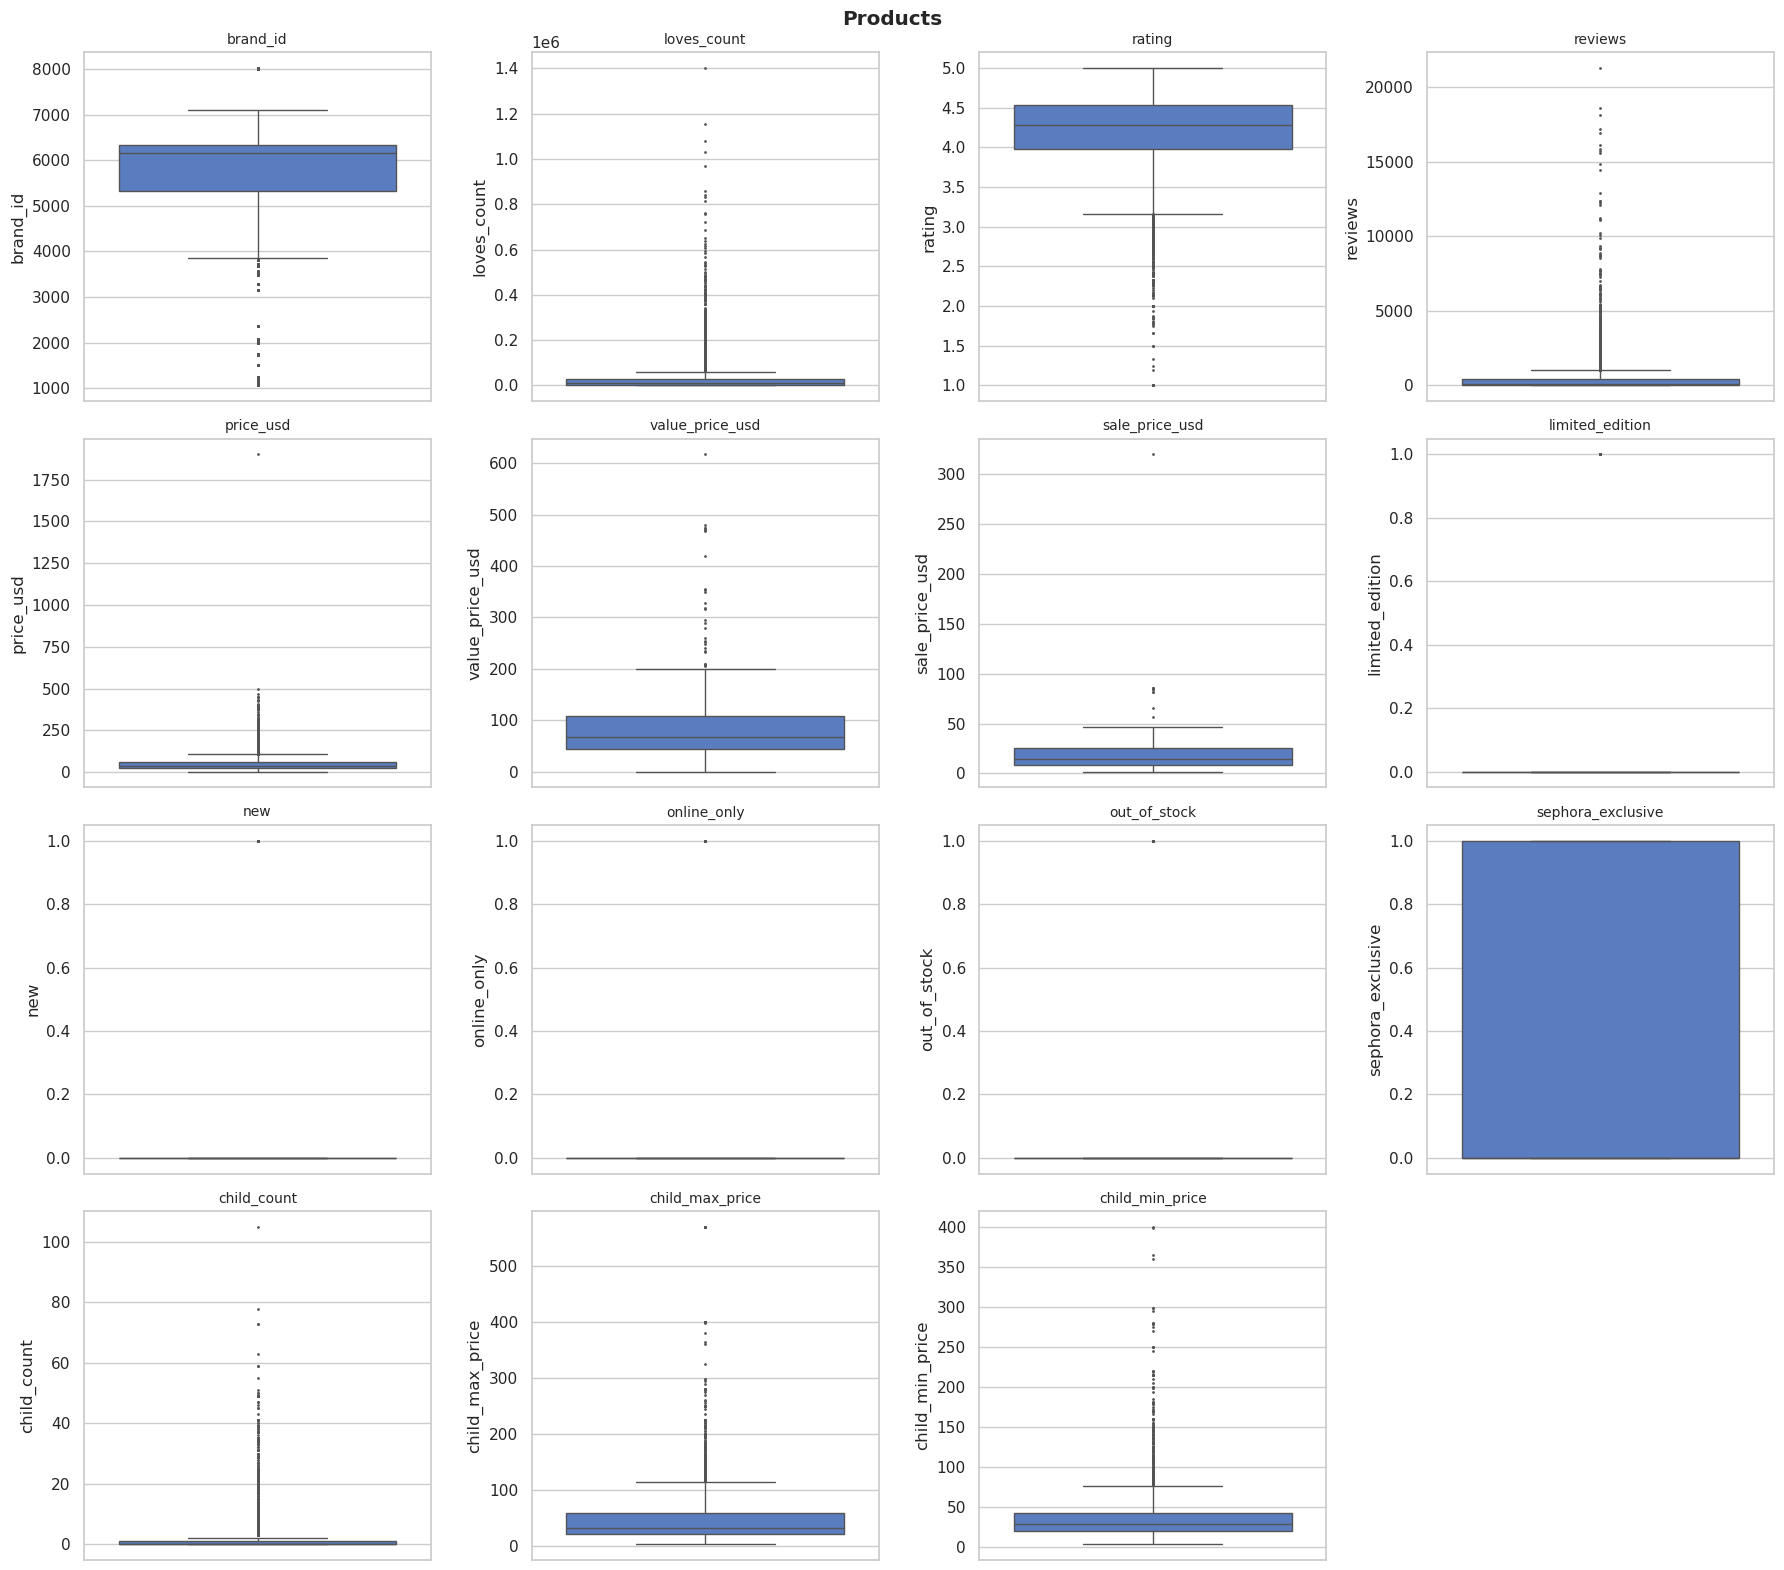

In [29]:
boxplot_grid(products, "Products")

## 6. Correlation Heatmaps

Pairwise Pearson correlation of all numeric columns.  
Helps detect redundant features and strong predictors of the target (rating).

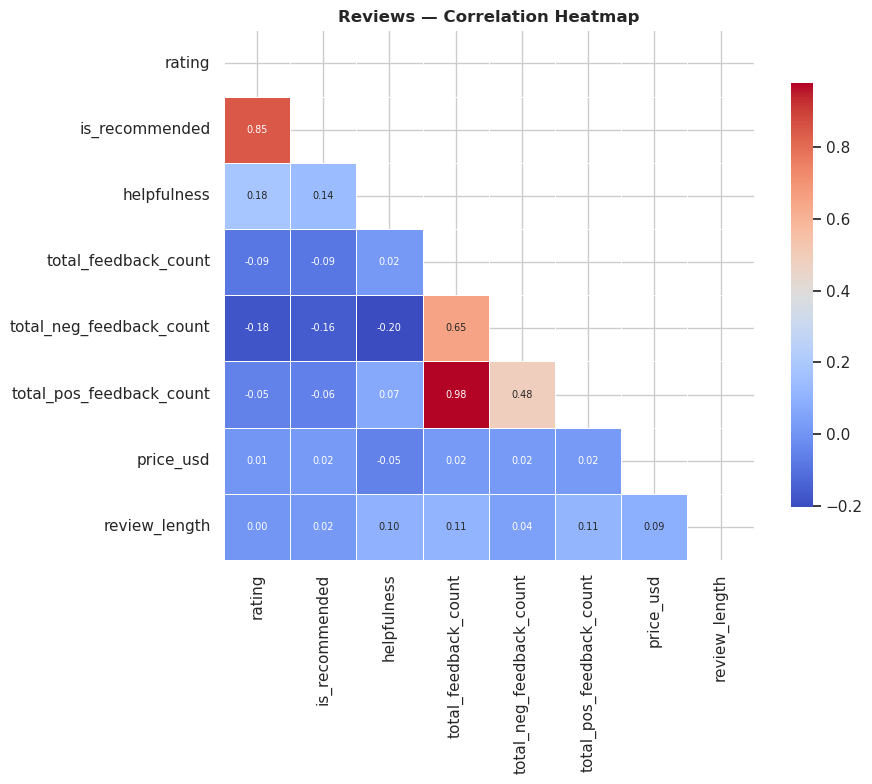

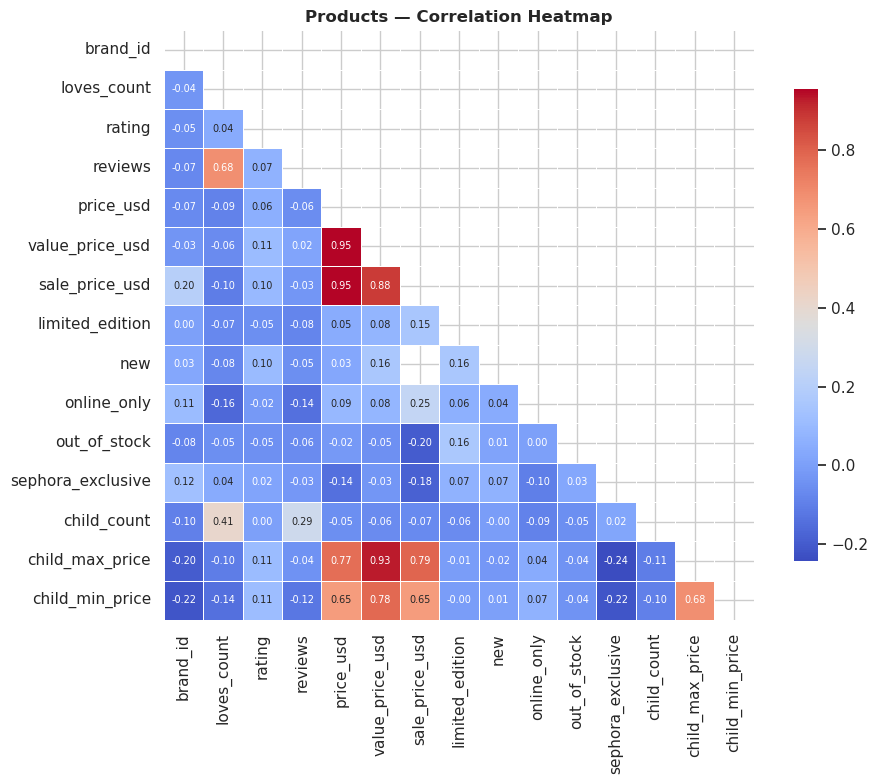

In [30]:
def corr_heatmap(df, title):
    corr = df.select_dtypes('number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True,
                fmt='.2f', annot_kws={'size': 7}, square=True,
                linewidths=0.4, cbar_kws={'shrink': 0.8})
    plt.title(title, fontweight='bold')
    plt.tight_layout()
    plt.show()

corr_heatmap(reviews,  'Reviews — Correlation Heatmap')
corr_heatmap(products, 'Products — Correlation Heatmap')

## 7. Brand & Category Analysis

A small number of brands account for most reviews and products, motivating a "top-N + Other" brand grouping in feature engineering.

### 7.1 Band Analysis

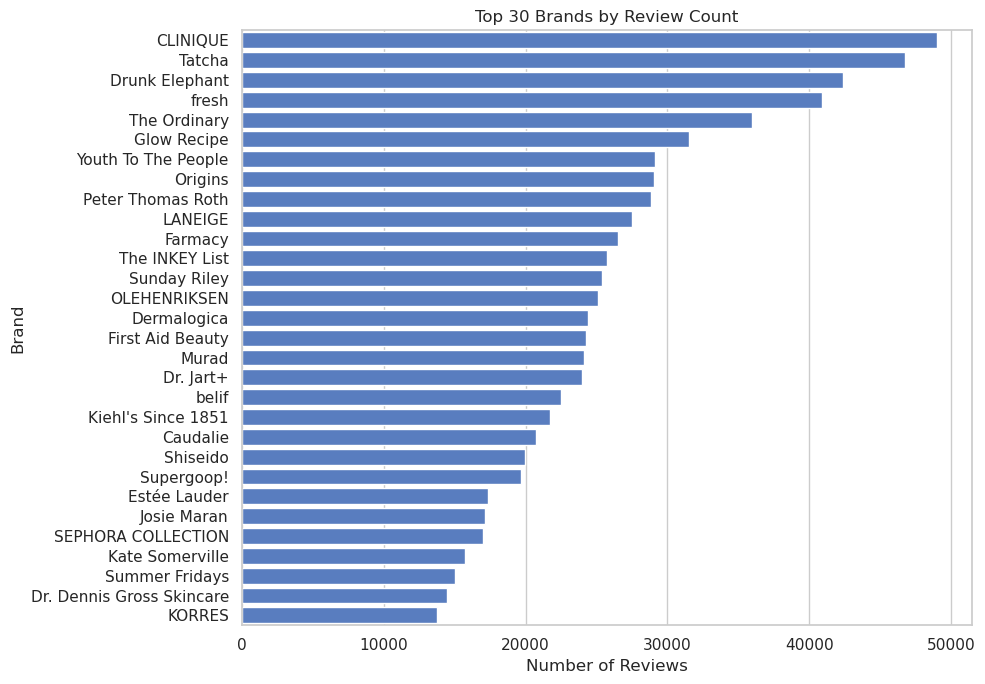

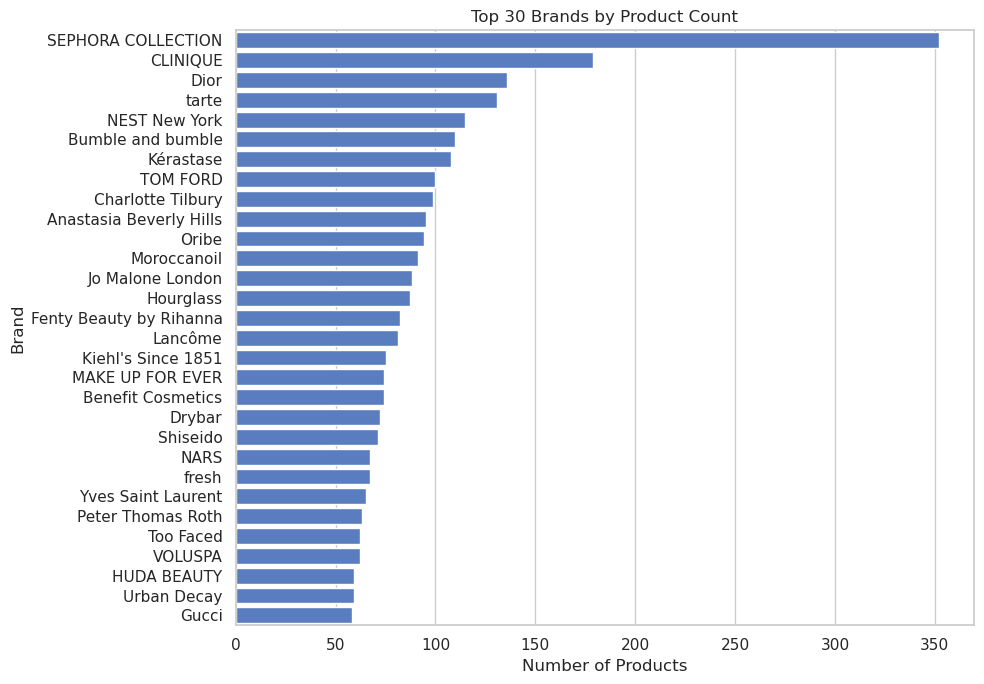

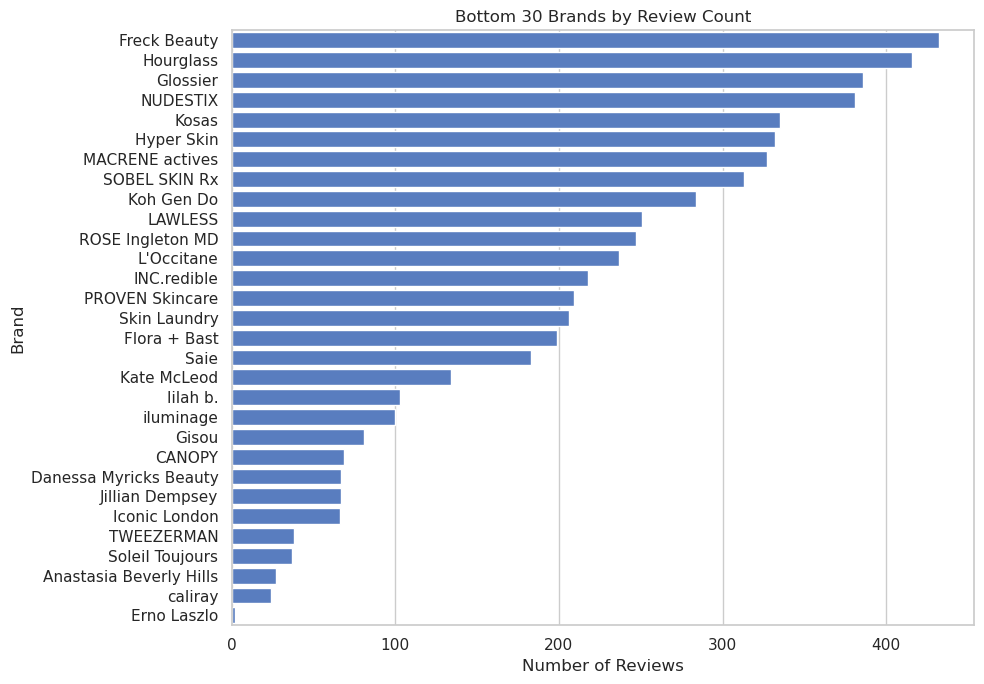

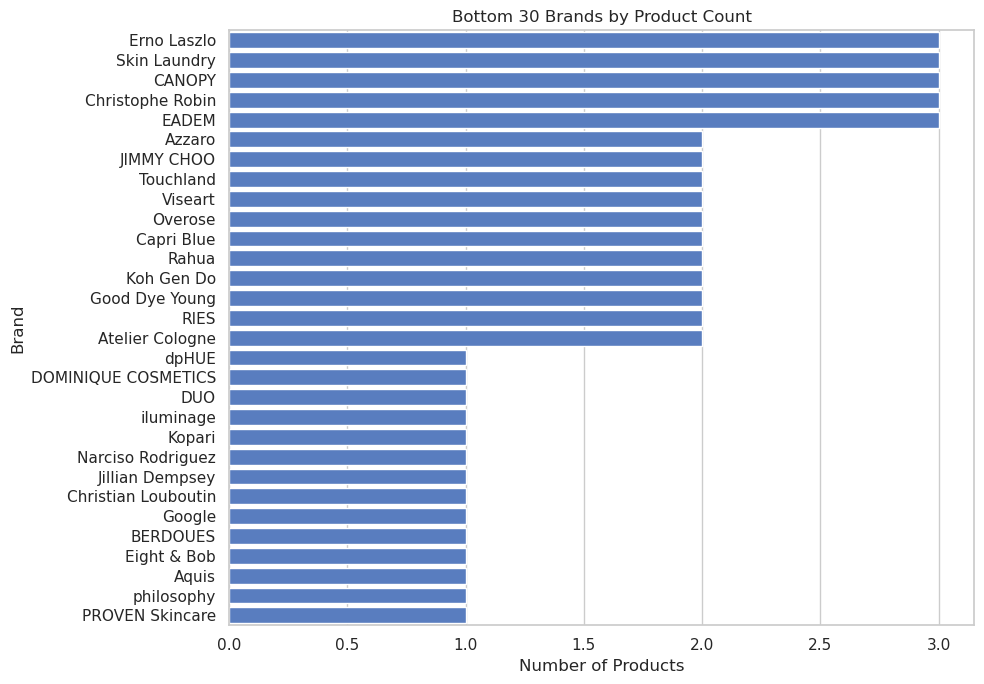

In [35]:
def brand_bar(series, n, title, xlabel):
    counts = series.value_counts().head(n)
    plt.figure(figsize=(10, 7))
    sns.barplot(x=counts.values, y=counts.index)
    plt.xlabel(xlabel)
    plt.ylabel("Brand")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Top 30
brand_bar(reviews["brand_name"],  30, "Top 30 Brands by Review Count",   "Number of Reviews")
brand_bar(products["brand_name"], 30, "Top 30 Brands by Product Count",  "Number of Products")

# Bottom 30
def bottom_brand_bar(series, n, title, xlabel):
    counts = series.value_counts().nsmallest(n).sort_values(ascending=False)
    plt.figure(figsize=(10, 7))
    sns.barplot(x=counts.values, y=counts.index)
    plt.xlabel(xlabel)
    plt.ylabel("Brand")
    plt.title(title)
    plt.tight_layout()
    plt.show()

bottom_brand_bar(reviews["brand_name"],  30, "Bottom 30 Brands by Review Count",  "Number of Reviews")
bottom_brand_bar(products["brand_name"], 30, "Bottom 30 Brands by Product Count", "Number of Products")

### 7.2 Category Analysis

In [36]:
for level in ["primary_category", "secondary_category", "tertiary_category"]:
    print(f"{level}: {products[level].nunique()} unique values")
    print(products[level].value_counts().head(10), "\n")

primary_category: 9 unique values
primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64 

secondary_category: 41 unique values
secondary_category
Women                        875
Hair Styling & Treatments    757
Eye                          711
Face                         659
Moisturizers                 551
Value & Gift Sets            498
Treatments                   466
Shampoo & Conditioner        431
Lip                          411
Cleansers                    361
Name: count, dtype: int64 

tertiary_category: 118 unique values
tertiary_category
Perfume                      568
Moisturizers                 386
Face Serums                  379
Rollerballs & Travel Size    287
Hair Styling Products        255
Shampoo                      238
Face Wash & Cleansers        217
Body 

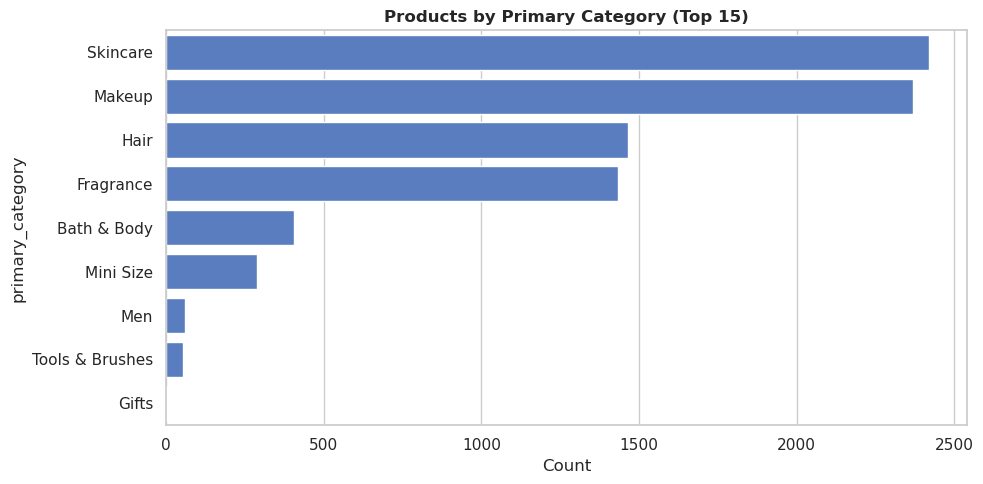

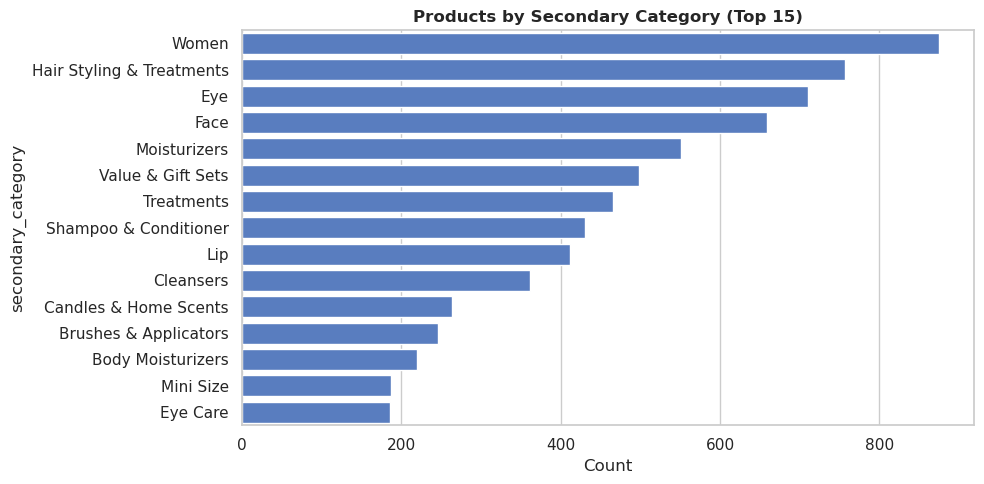

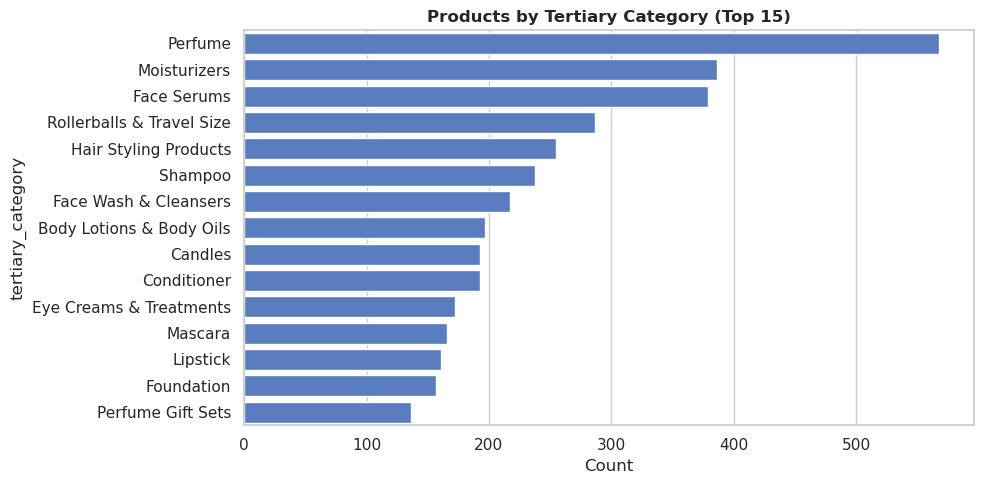

In [32]:
for level in ['primary_category', 'secondary_category', 'tertiary_category']:
    counts = products[level].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(f'Products by {level.replace("_", " ").title()} (Top 15)', fontweight='bold')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

## 8. Price Analysis

Does price correlate with rating or popularity? Price is right-skewed, so a log transform will be applied in feature engineering.

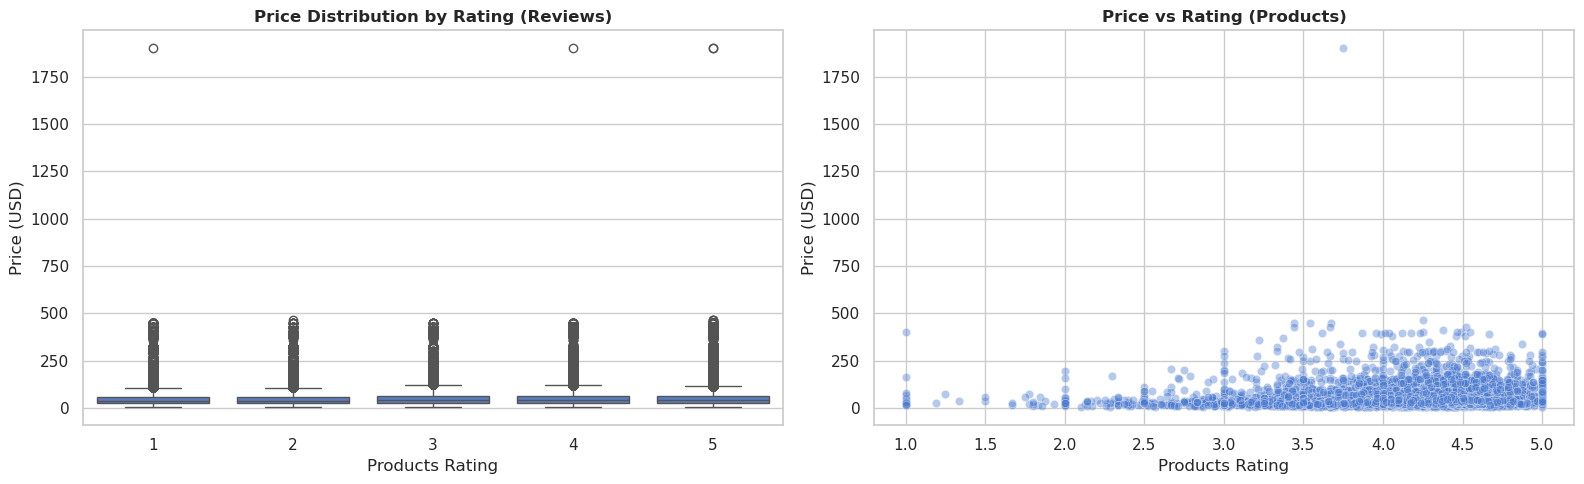

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=reviews, x='rating', y='price_usd', ax=axes[0])
axes[0].set_title('Price Distribution by Rating (Reviews)', fontweight='bold')
axes[0].set_xlabel('Products Rating')
axes[0].set_ylabel('Price (USD)')

sns.scatterplot(data=products, x='rating', y='price_usd', alpha=0.4, ax=axes[1])
axes[1].set_title('Price vs Rating (Products)', fontweight='bold')
axes[1].set_xlabel('Products Rating')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

## 9. Helpfulness Analysis

Helpfulness score measures how useful readers found a review (~51% of reviews have no score).  
We explore what drives it — rating, review length, and brand.

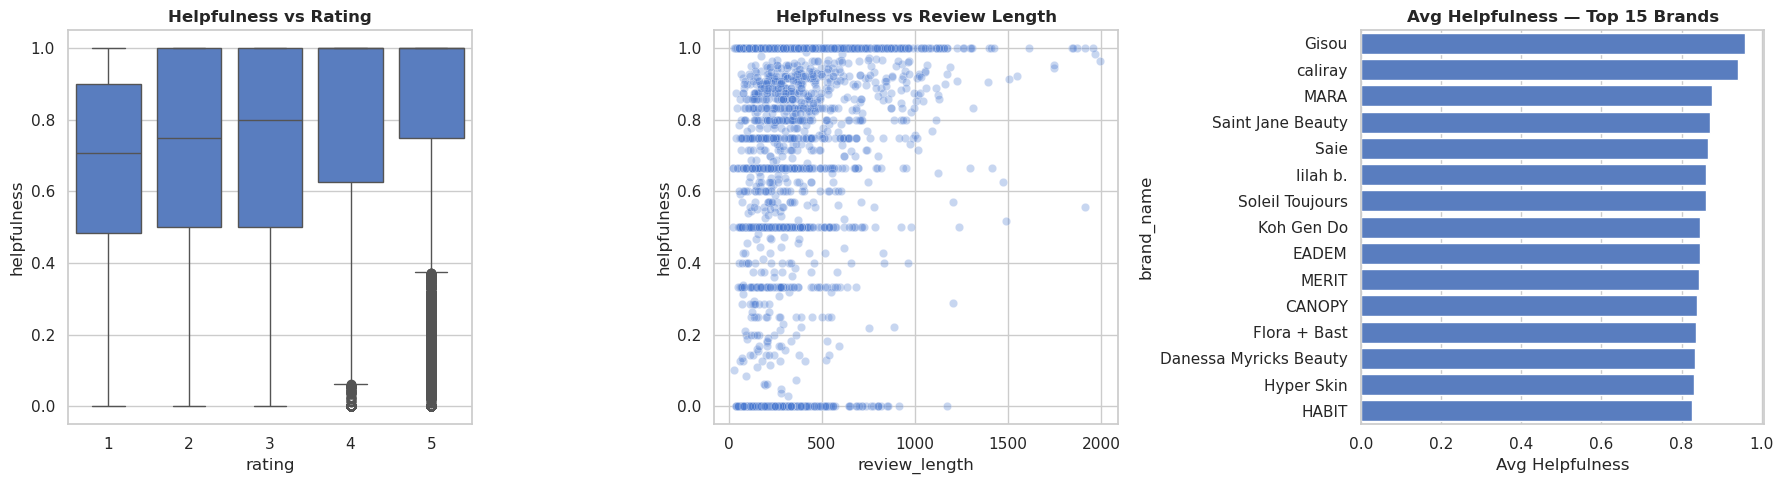

Correlation (review_length, helpfulness) = 0.103


In [13]:
reviews['review_length'] = reviews['review_text'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=reviews, x='rating', y='helpfulness', ax=axes[0])
axes[0].set_title('Helpfulness vs Rating', fontweight='bold')

sample = reviews.dropna(subset=['helpfulness']).sample(3000, random_state=42)
sns.scatterplot(data=sample, x='review_length', y='helpfulness', alpha=0.3, ax=axes[1])
axes[1].set_title('Helpfulness vs Review Length', fontweight='bold')

brand_help = (reviews.groupby('brand_name')['helpfulness']
              .mean().sort_values(ascending=False).head(15))
sns.barplot(x=brand_help.values, y=brand_help.index, ax=axes[2])
axes[2].set_title('Avg Helpfulness — Top 15 Brands', fontweight='bold')
axes[2].set_xlabel('Avg Helpfulness')

plt.tight_layout()
plt.show()

r = reviews[['review_length', 'helpfulness']].dropna().corr().iloc[0, 1]
print(f'Correlation (review_length, helpfulness) = {r:.3f}')

In [39]:
pd.set_option("display.max_colwidth", None)

reviews.sort_values("helpfulness", ascending=False)[
    ["brand_name","rating","helpfulness","review_text"]
].head(20)

,brand_name,rating,helpfulness,review_text
37,LANEIGE,5,1.0,"I am super impressed with this lip mask. I use it at bedtime and wake up with soft lips! ( I struggle with cracked and peeling lips every winter ) I also use it on top of my lip liner in the morning for a plumped, soft look."
1094377,Jack Black,5,1.0,"Have used this lotion for two weeks now, skin feels really good, ultra moisturized. Easily one of the best lotions on the market. You get what you pay for. This will be a staple in my routine from now on."
0,NUDESTIX,5,1.0,"I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cleanse and it has completely changed my skin (for the better). The make-up melt is oil based and removes all of your makeup super easily. I follow-up with this water based cleanser, and I also use this just by itself when I’m not wearing make-up. It leaves the skin gently cleansed, but without stripping the skin. 10/10 recommend combining with the make-up melt. It’s perfection!"
5,LANEIGE,4,1.0,"The scent isn’t my favourite but it works great! I put it on every night before I go to sleep and every morning I wake up with smooth, moisturizer and soft. Packaging is amazing as well"
1094376,Estée Lauder,5,1.0,Really good for dry patchy skin!!! My skin has been very dry lately and this wash is perfect you only need a little it gets very foamy after adding water!!!
8,LANEIGE,5,1.0,"I love this stuff. I first had the sample size from a Sephora Birthday gift, and once I had run through it I knew it was a purchase. I live in an incredibly dry environment, great for macarons, but terrible for my skin. This lip mask helps to keep my lips from becoming too chapped."
9,LANEIGE,5,1.0,"I purchased the Sweet Candy scent at my local Sephora and I am OBSESSED!! I will be honest, the scent is a bit strong - but they’re all strongly scented. My lips are so soft. 10/10!"
1094361,Hourglass,5,1.0,Bought the travel size to test if I liked it. Immediately went and bought the full size. Love how much this lathers and the slight fragrance is nice. Leaves my skin feeling extremely cleansed.
1094364,Sulwhasoo,4,1.0,This is a nice light daytime moisturizer for the summer
1094367,Drunk Elephant,5,1.0,I love that you have to mix the two items for the vitamin C


## 10. Loves-Count Analysis

`loves_count` is our product popularity signal. Heavily right-skewed — a handful of viral products dominate — so we log-transform it as a feature.

In [14]:
top_loved = (products.sort_values('loves_count', ascending=False)
             [['product_name', 'brand_name', 'loves_count', 'rating', 'price_usd']]
             .head(15))
display(top_loved)

,product_name,brand_name,loves_count,rating,price_usd
6242,Soft Pinch Liquid Blush,Rare Beauty by Selena Gomez,1401068,4.5356,23.0
5249,Radiant Creamy Concealer,NARS,1153594,4.3080,32.0
4431,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,1081315,4.3508,24.0
6434,Cream Lip Stain Liquid Lipstick,SEPHORA COLLECTION,1029051,4.3201,15.0
2523,Gloss Bomb Universal Lip Luminizer,Fenty Beauty by Rihanna,968317,4.6357,21.0
2524,Pro Filt’r Soft Matte Longwear Liquid Foundation,Fenty Beauty by Rihanna,856497,4.0356,40.0
5250,Blush,NARS,840076,4.6643,32.0
247,Brow Wiz Ultra-Slim Precision Brow Pencil,Anastasia Beverly Hills,834189,4.4056,25.0
4458,Translucent Loose Setting Powder,Laura Mercier,813497,4.5029,43.0
7648,Niacinamide 10% + Zinc 1% Oil Control Serum,The Ordinary,763168,4.2439,6.0


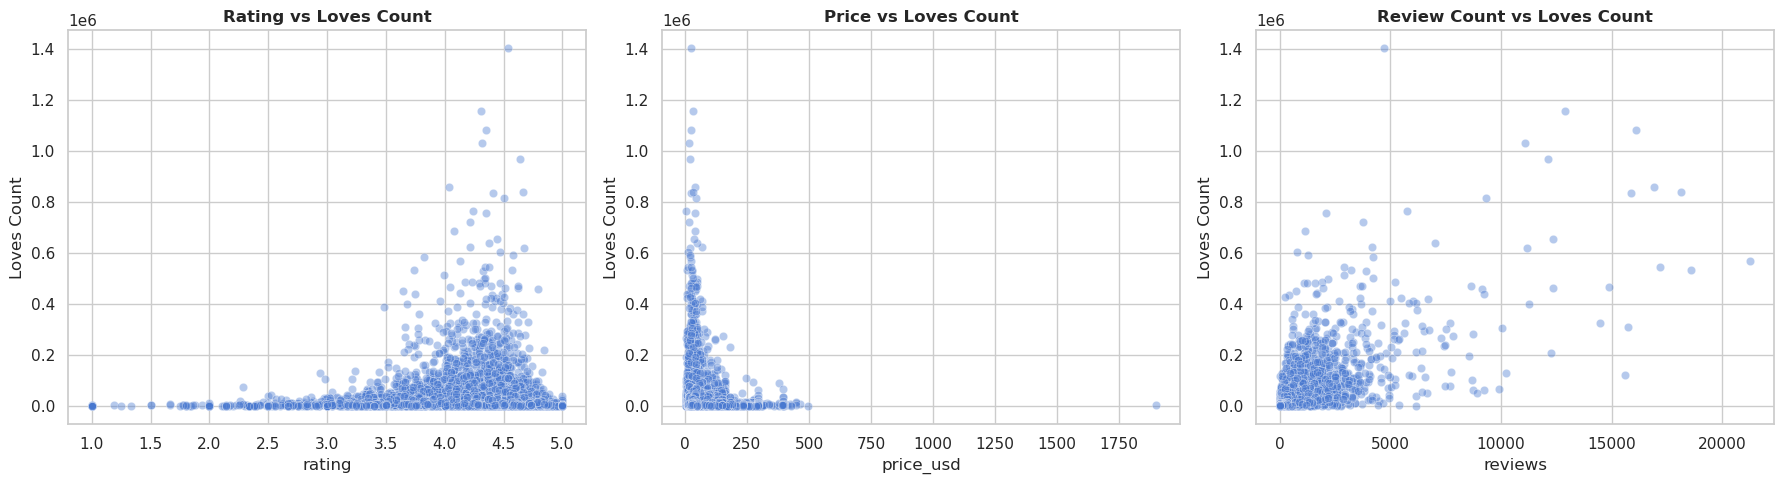

Skewness — loves_count : 7.25
Skewness — log1p(loves): -1.48


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=products, x='rating',    y='loves_count', alpha=0.4, ax=axes[0])
axes[0].set_title('Rating vs Loves Count', fontweight='bold')

sns.scatterplot(data=products, x='price_usd', y='loves_count', alpha=0.4, ax=axes[1])
axes[1].set_title('Price vs Loves Count', fontweight='bold')

sns.scatterplot(data=products, x='reviews',   y='loves_count', alpha=0.4, ax=axes[2])
axes[2].set_title('Review Count vs Loves Count', fontweight='bold')

for ax in axes:
    ax.set_ylabel('Loves Count')
plt.tight_layout()
plt.show()

print('Skewness — loves_count :', round(products['loves_count'].skew(), 2))
print('Skewness — log1p(loves):', round(np.log1p(products['loves_count']).skew(), 2))

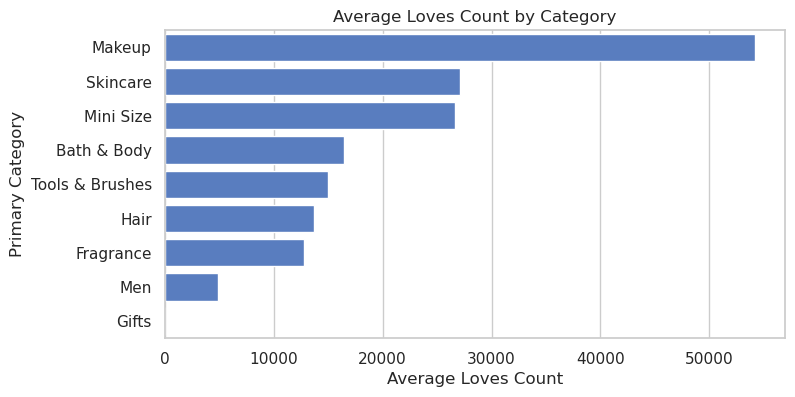

In [41]:
category_love = products.groupby("primary_category")["loves_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    x=category_love.values,
    y=category_love.index
)

plt.xlabel("Average Loves Count")
plt.ylabel("Primary Category")
plt.title("Average Loves Count by Category")

plt.show()

---
## Summary

| Step | Input | Output |
|---|---|---|
| Ingestion | 5 review CSVs + 1 product CSV | Combined DataFrames (1,094,411 reviews / 8,494 products) |
| Storage | DataFrames | Parquet files in `curated/` layer |
| Athena | Parquet files | `sephora_reviews`, `sephora_products` external tables |
| Schema audit | DataFrames | Missing-value map; dtype confirmed |
| Distributions | Numeric columns | Right-skew confirmed for price, loves_count, reviews |
| Correlations | Numeric columns | Moderate: reviews↔loves_count; weak: price↔rating |
| Brand/category | Categorical columns | Top-30 brands dominate; Makeup is focus category |
| Price | price_usd | No clear linear price–rating relationship |
| Helpfulness | helpfulness | Weak correlation with length; brand effect stronger |
| Loves-count | loves_count | Extreme right-skew; log transform reduces skewness |

**Key decisions for feature engineering (Notebook 02):**
- Log-transform `price_usd`, `loves_count`, `reviews`
- Group long-tail brands into "Top-30 + Other"
- Focus product modelling on the **Makeup** primary category
- Use TF-IDF on `review_text`; VADER for sentiment

Next: `02_data_transformation_and_feature_engineering.ipynb`